# 01 · Exploratory Data Analysis
**Heavy Equipment Selling Price Prediction Challenge**

Goal: understand data quality and the main drivers of `TargetValue` (sale price in USD) before modelling.
Findings here motivate the cleaning rules implemented in [`src/features.py`](../src/features.py).

> Set `DATA_DIR` below to wherever `train.csv` lives (see `data/README.md`).

In [5]:
import sys; sys.path.append('..')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as cfg

sns.set_theme(style='whitegrid')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
# DATA_DIR = Path('Downloads/heavy-equipment-price-prediction (1)/heavy-equipment-price-prediction/notebooks/data')   # on Kaggle: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
print(f'train: {train.shape} | test: {test.shape}')
train.head().T

/tmp/ipykernel_1194/4036241288.py:15: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/content/train.csv')


train: (138701, 50) | test: (15000, 49)


,0,1,2,3,4
TransactionID,1139309,1139316,1139317,1139322,1139333
TargetValue,57000.0,26500.0,21000.0,27000.0,21500.0
AssetID,117665,1001282,772709,902010,1036259
ProductConfigID,88,4616,1948,3550,36014
DataOriginCode,ACH138,ACH138,ACH138,ACH138,ACH138
VendorPartnerID,GTX,GTX,GTX,GTX,GTX
ManufactureYear,1997,2005,1994,2002,2009
OperationalHoursMeter,4640.0,508.0,11540.0,4883.0,302.0
UtilizationTier,Low,Low,High,High,Low
TransactionDate,2005-03-26,2009-12-18,2005-08-26,2006-11-17,2010-08-27


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,2.186276e+06,1.128497e+06,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,4.152187e+04,2.636113e+04,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,1.204814e+06,5.287376e+05,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,7.286422e+03,7.542422e+03,39.0,1693.0,3852.0,11873.0,37209.0
ManufactureYear,138701.0,1.891641e+03,3.069920e+02,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4.553719e+03,2.792204e+04,0.0,0.0,1620.0,5001.0,1729600.0


## 1. Missing values
Many columns are sparse. Columns that are almost empty carry no usable signal and are dropped (`col4`, `col5`, `col18`, `col19`).

Columns with missing values : 35 of 50
Columns with > 50% missing : 24
Columns with > 80% missing : 15
Columns with > 90% missing : 4
Near-empty columns: ['col19', 'col18', 'col5', 'col4']


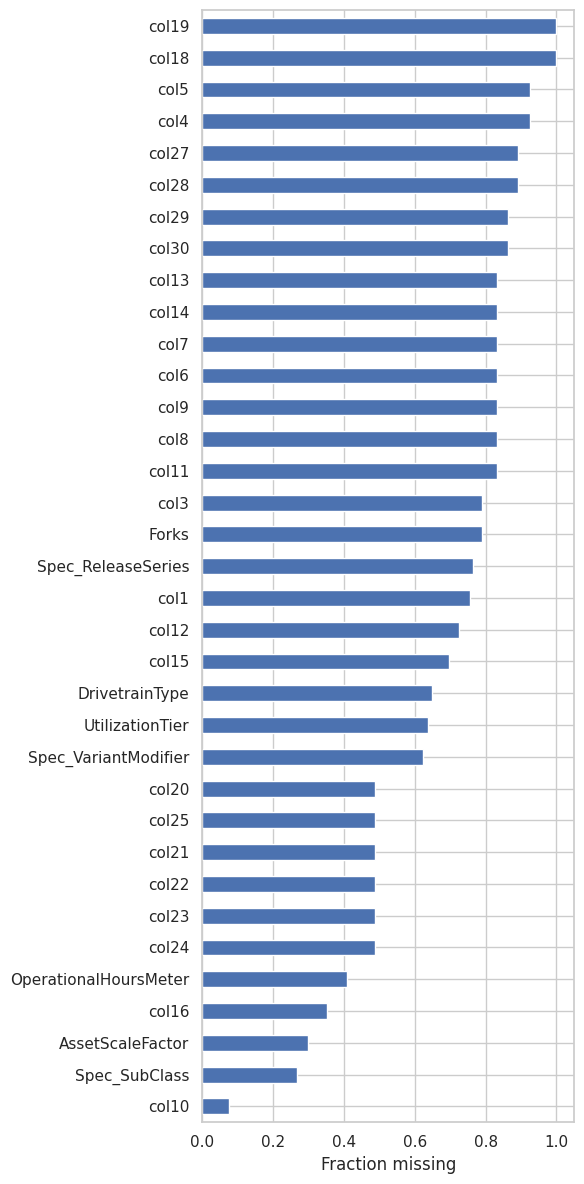

In [8]:
missing = train.isna().mean().sort_values(ascending=False)
print(f'Columns with missing values : {(missing > 0).sum()} of {train.shape[1]}')
for t in (0.5, 0.8, 0.9):
    print(f'Columns with > {t:.0%} missing : {(missing > t).sum()}')
print('Near-empty columns:', list(missing[missing > 0.9].index))

ax = missing[missing > 0].plot(kind='barh', figsize=(6, 12))
ax.set_xlabel('Fraction missing'); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG_DIR / 'missing_values.png', dpi=150); plt.show()

## 2. Target distribution
`TargetValue` is right-skewed, so the models are trained on `log1p(TargetValue)` and scored with RMSLE.

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64


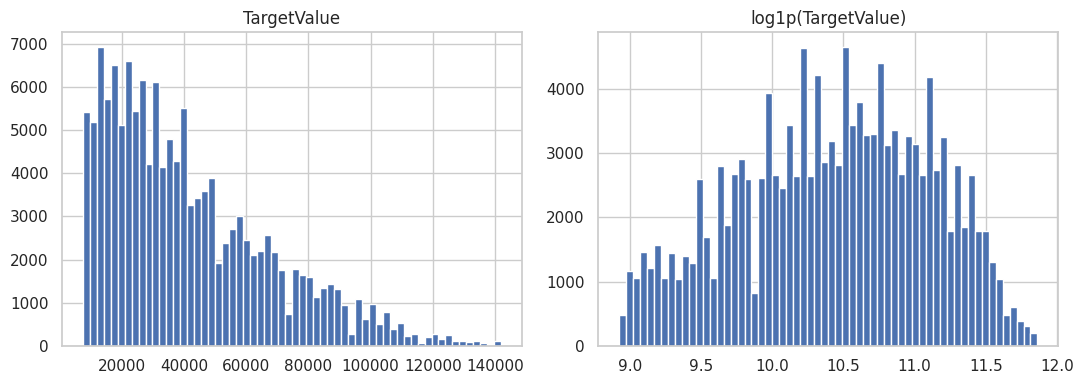

In [9]:
print(train[cfg.TARGET].describe())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
train[cfg.TARGET].hist(bins=60, ax=ax[0]); ax[0].set_title('TargetValue')
np.log1p(train[cfg.TARGET]).hist(bins=60, ax=ax[1]); ax[1].set_title('log1p(TargetValue)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'target_distribution.png', dpi=150); plt.show()

## 3. Numerical columns
`ManufactureYear` contains a sentinel value (**1001**) that is clearly not a year; it is treated as missing.
`OperationalHoursMeter` is ~41% missing and has an extreme right tail.

ManufactureYear == 1001 : 10.6% of rows
OperationalHoursMeter missing: 40.8%


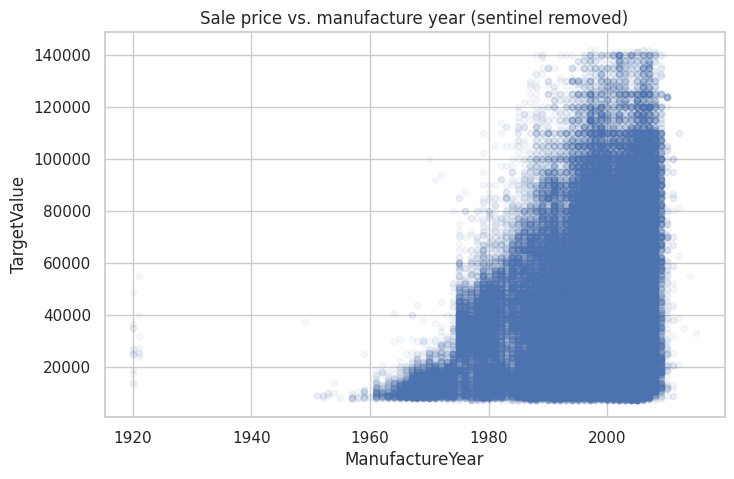

,ManufactureYear,OperationalHoursMeter,TargetValue
ManufactureYear,1.000000,-0.003876,0.276962
OperationalHoursMeter,-0.003876,1.000000,0.001994
TargetValue,0.276962,0.001994,1.000000


In [10]:
print('ManufactureYear == 1001 :', f"{(train['ManufactureYear'] == cfg.MANUFACTURE_YEAR_SENTINEL).mean():.1%} of rows")
print('OperationalHoursMeter missing:', f"{train['OperationalHoursMeter'].isna().mean():.1%}")

df = train.copy()
df['ManufactureYear'] = df['ManufactureYear'].replace(cfg.MANUFACTURE_YEAR_SENTINEL, np.nan)
df[cfg.DATE_COL] = pd.to_datetime(df[cfg.DATE_COL])
df['TransactionYear'] = df[cfg.DATE_COL].dt.year

df.plot.scatter(x='ManufactureYear', y=cfg.TARGET, alpha=0.05, figsize=(8, 5),
                title='Sale price vs. manufacture year (sentinel removed)')
plt.savefig(FIG_DIR / 'manufacture_year_vs_price.png', dpi=150); plt.show()

df[['ManufactureYear', 'OperationalHoursMeter', cfg.TARGET]].corr()

## 4. Time dimension

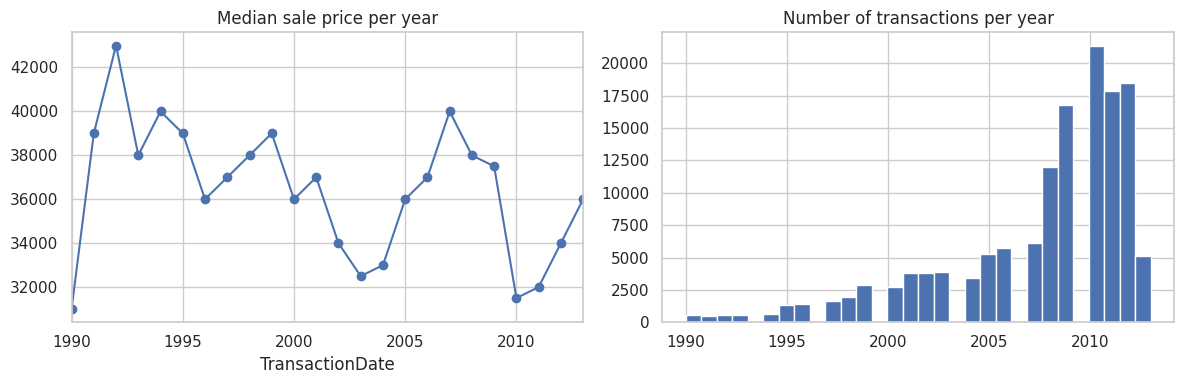

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.set_index(cfg.DATE_COL)[cfg.TARGET].resample('YE').median().plot(marker='o', ax=ax[0], title='Median sale price per year')
df['TransactionYear'].hist(bins=30, ax=ax[1]); ax[1].set_title('Number of transactions per year')
plt.tight_layout(); plt.savefig(FIG_DIR / 'median_price_over_time.png', dpi=150); plt.show()

Prices and volumes drift over time, so a **chronological** train/validation split (train on the past, validate on the most recent 15%) is used instead of a random split.

## 5. Categorical features

TransactionDate              3676
Spec_FullDescriptor          3505
Spec_BaseClass               1249
Spec_SubClass                 147
Spec_VariantModifier          132
Spec_ReleaseSeries            113
FunctionalClassification       65
RegionCode                     53
VendorPartnerID                31
col22                          27
col21                          18
col15                          15
col10                          11
col27                           9
DrivetrainType                  8
DataOriginCode                  6
col7                            6
AssetScaleFactor                6
InventoryGroupDescription       6
InventoryGroupCategory          6
col28                           5
col1                            4
col12                           4
UtilizationTier                 3
col3                            3
col8                            3
col23                           3
CabinType                       3
col25                           3
col24         

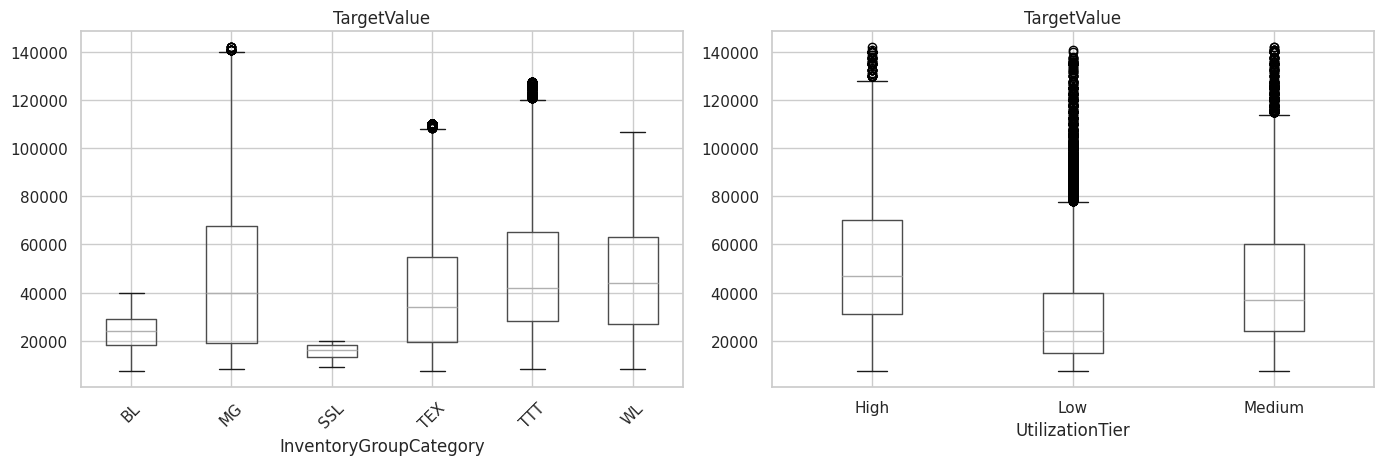

In [12]:
print(df.select_dtypes(exclude='number').nunique().sort_values(ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column=cfg.TARGET, by='InventoryGroupCategory', rot=45, ax=ax[0])
df.boxplot(column=cfg.TARGET, by='UtilizationTier', ax=ax[1])
plt.suptitle(''); plt.tight_layout(); plt.show()

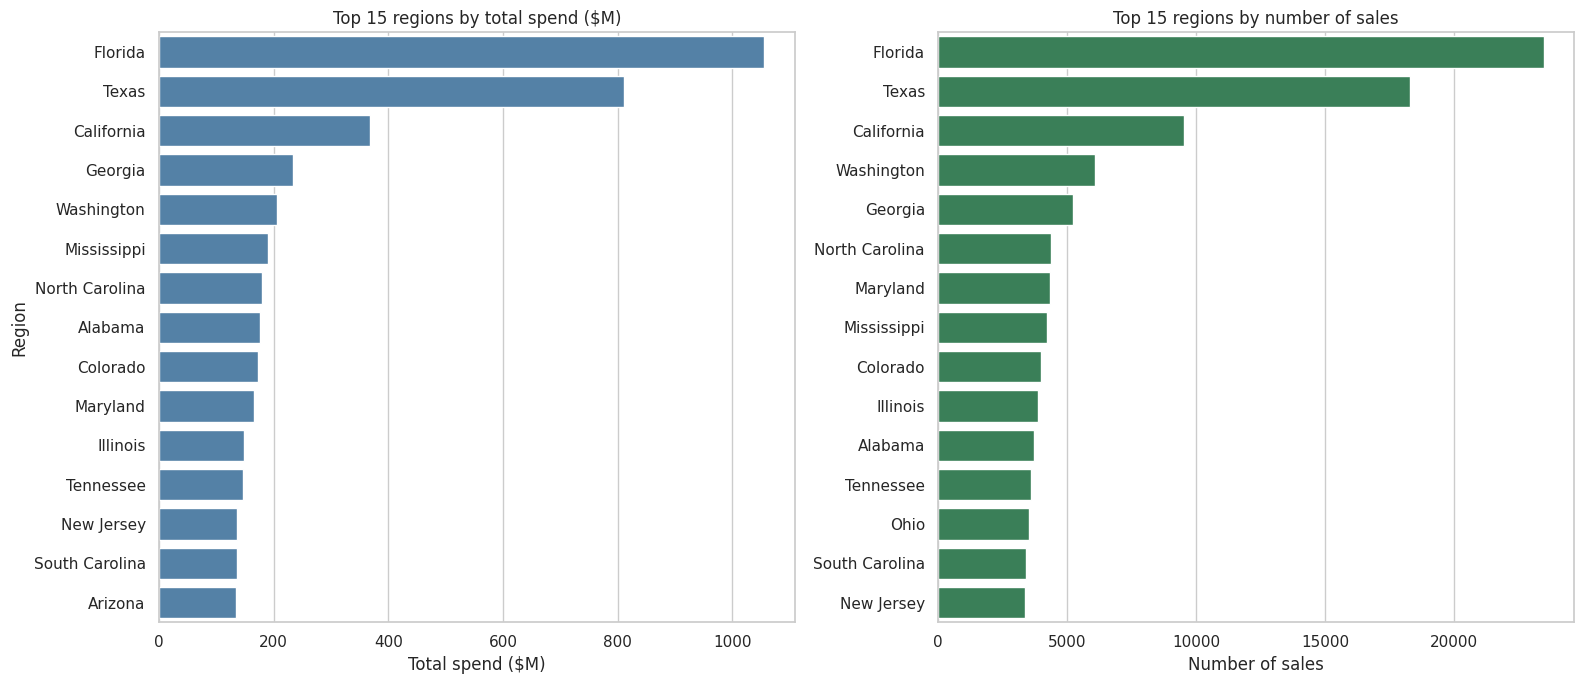

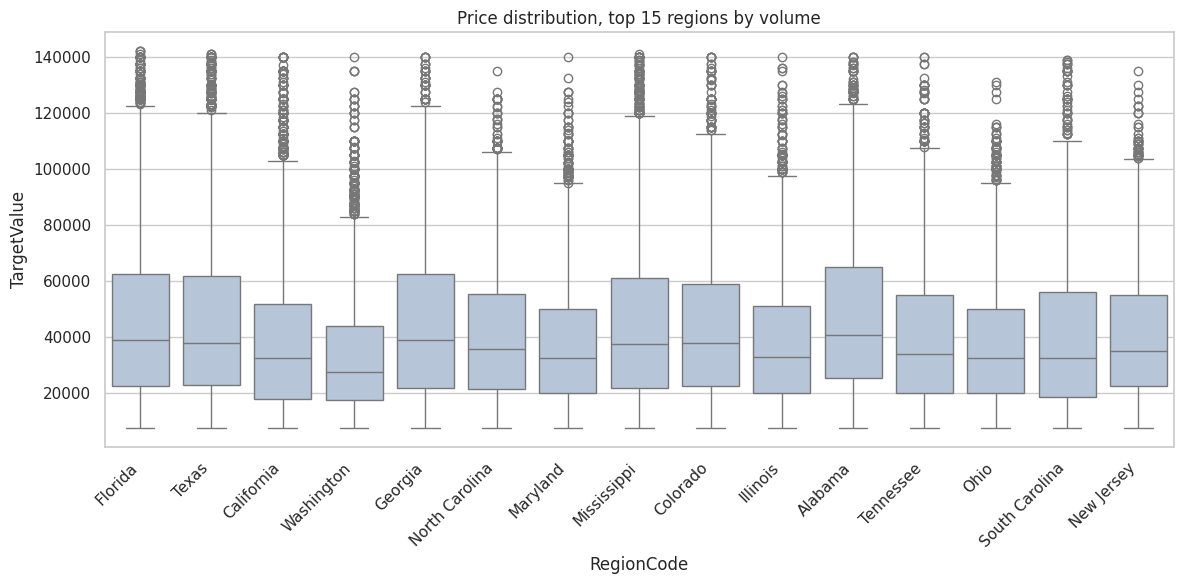

In [13]:
region = (df.groupby('RegionCode')[cfg.TARGET]
            .agg(total_spend='sum', num_purchases='count', avg_price='mean', median_price='median'))
top_spend = region.sort_values('total_spend', ascending=False).head(15)
top_volume = region.sort_values('num_purchases', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=top_spend['total_spend'] / 1e6, y=top_spend.index, ax=axes[0], color='steelblue')
axes[0].set(title='Top 15 regions by total spend ($M)', xlabel='Total spend ($M)', ylabel='Region')
sns.barplot(x=top_volume['num_purchases'], y=top_volume.index, ax=axes[1], color='seagreen')
axes[1].set(title='Top 15 regions by number of sales', xlabel='Number of sales', ylabel='')
plt.tight_layout(); plt.savefig(FIG_DIR / 'region_spend_vs_volume.png', dpi=150); plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['RegionCode'].isin(top_volume.index)], x='RegionCode', y=cfg.TARGET,
            order=top_volume.index, color='lightsteelblue')
plt.xticks(rotation=45, ha='right'); plt.title('Price distribution, top 15 regions by volume')
plt.tight_layout(); plt.savefig(FIG_DIR / 'region_price_distribution.png', dpi=150); plt.show()

## 6. Duplicates and outliers
`OperationalHoursMeter` has an extreme tail (max is ~67x the 99th percentile) while `TargetValue` does not. Values far above the 99.5th percentile of the training data (and exact zeros) are treated as meter errors and set to missing; the remainder is log-transformed.

Duplicate rows       : 0
Duplicate TransactionID: 0
p50          1620.0
p75          5001.0
p90          9348.0
p95         13031.0
p98         19313.0
p99         25796.0
p99.5       35778.0
p99.9      412138.0
p99.99    1201334.0
dtype: float64


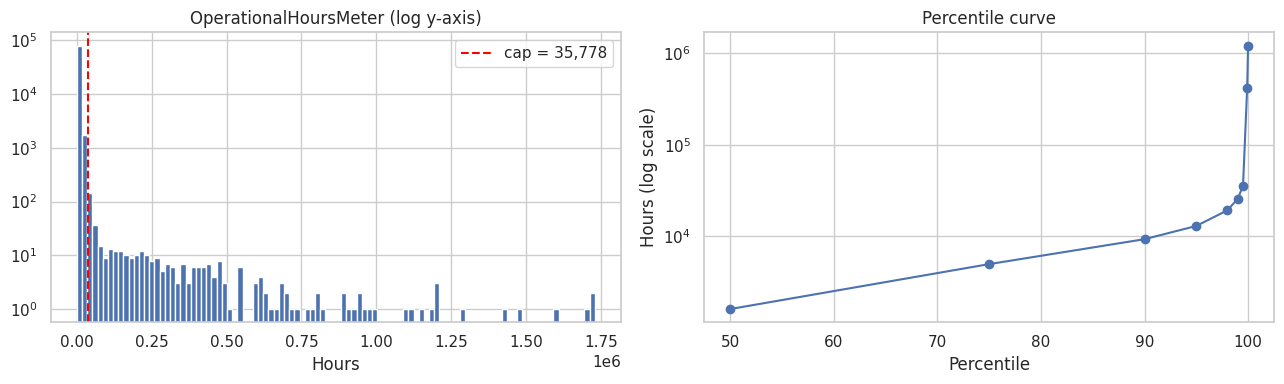

Rows above cap: 411 (0.50% of non-missing)


In [14]:
print('Duplicate rows       :', train.duplicated().sum())
print('Duplicate TransactionID:', train[cfg.ID_COL].duplicated().sum())

hours = df['OperationalHoursMeter'].dropna()
pcts = [0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 0.995, 0.999, 0.9999]
print(pd.Series({f'p{p*100:g}': hours.quantile(p) for p in pcts}).round(0))

cap = hours.quantile(cfg.HOURS_CAP_QUANTILE)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(hours, bins=100); ax[0].set_yscale('log'); ax[0].axvline(cap, color='red', ls='--', label=f'cap = {cap:,.0f}')
ax[0].set(title='OperationalHoursMeter (log y-axis)', xlabel='Hours'); ax[0].legend()
ax[1].plot([p * 100 for p in pcts], [hours.quantile(p) for p in pcts], marker='o'); ax[1].set_yscale('log')
ax[1].set(title='Percentile curve', xlabel='Percentile', ylabel='Hours (log scale)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'operational_hours_outliers.png', dpi=150); plt.show()
print(f'Rows above cap: {(hours > cap).sum()} ({(hours > cap).mean():.2%} of non-missing)')